In [2]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# For handling imbalance
from imblearn.over_sampling import SMOTE

In [4]:
# Load Your CSV
df = pd.read_csv("diabetes-data.csv")

In [5]:
#First Five Rows of Data
print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [6]:
#Check Dataset Structure
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [7]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)


Shape of dataset: (768, 9)

Column names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [8]:
#Summary Statistics
print(df.describe())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [9]:
#Create a Safe Copy and Prepare Important Columns
data = df.copy()
print(data.head())

x = data.drop("Outcome",axis=1)
y = data["Outcome"]
print("Features:")
print(x.columns)
print("\nTarget:")
print(y.name)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Features:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Target:
Outcome


In [10]:
#Checking for Missing Values
print(data.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [11]:
# in precentage
missing_percentage = data.isnull().mean()*100
print(missing_percentage)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64


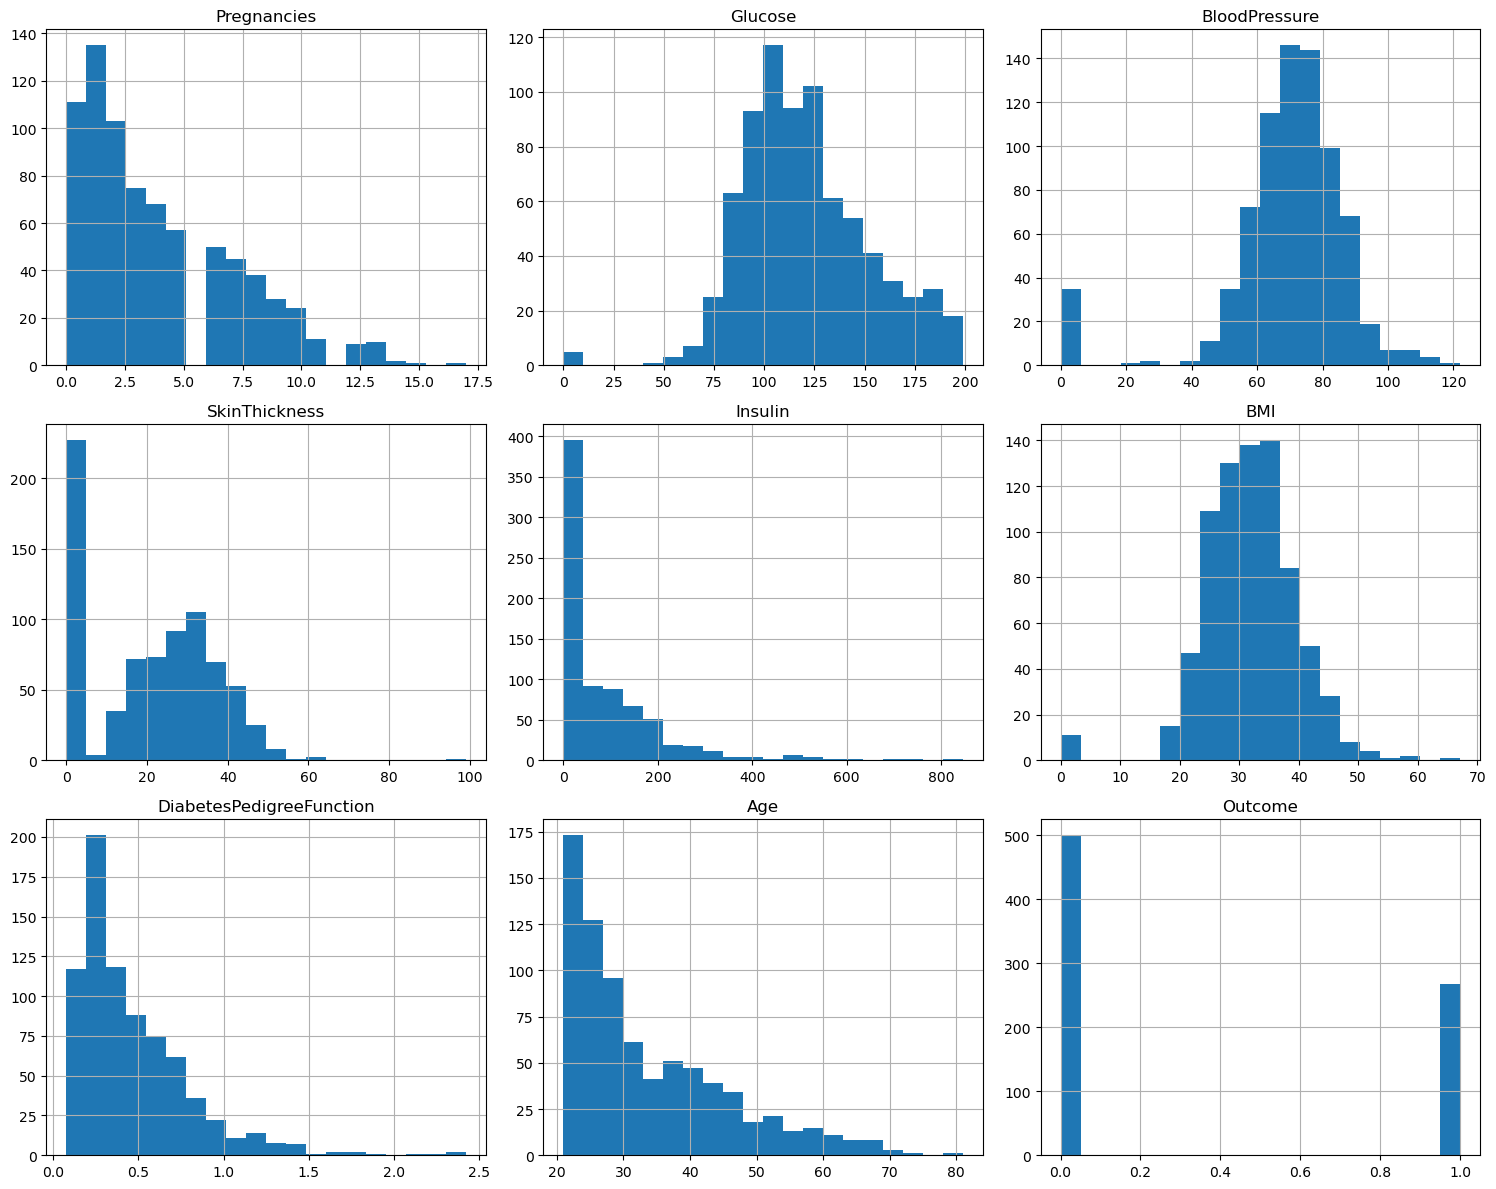

In [12]:
#Visualizing Data Distributions with Histograms
data.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

In [13]:
#Fix Zero Values & undestand data
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_columns:
    print(col, ":", (data[col] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [14]:
#fix zero value(to median replace)
for col in zero_columns:
    data[col] = data[col].replace(0,np.nan)
    data[col] = data[col].fillna(data[col].median())
print(data[zero_columns].isnull().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [15]:
#check size of dataset
rows, columns = data.shape
print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 768
Number of Columns: 9


Outcome
0    500
1    268
Name: count, dtype: int64


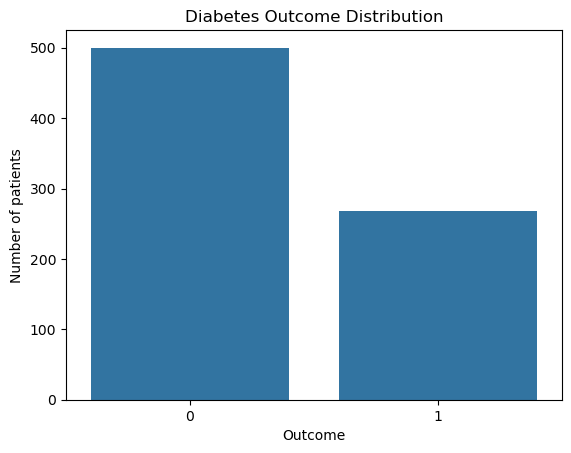

In [16]:
#Check how many people has diabetes
print(data["Outcome"].value_counts())
sns.countplot(x="Outcome", data=data)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of patients")

plt.show()

In [17]:
#in percentage
print(data["Outcome"].value_counts(normalize=True)*100)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


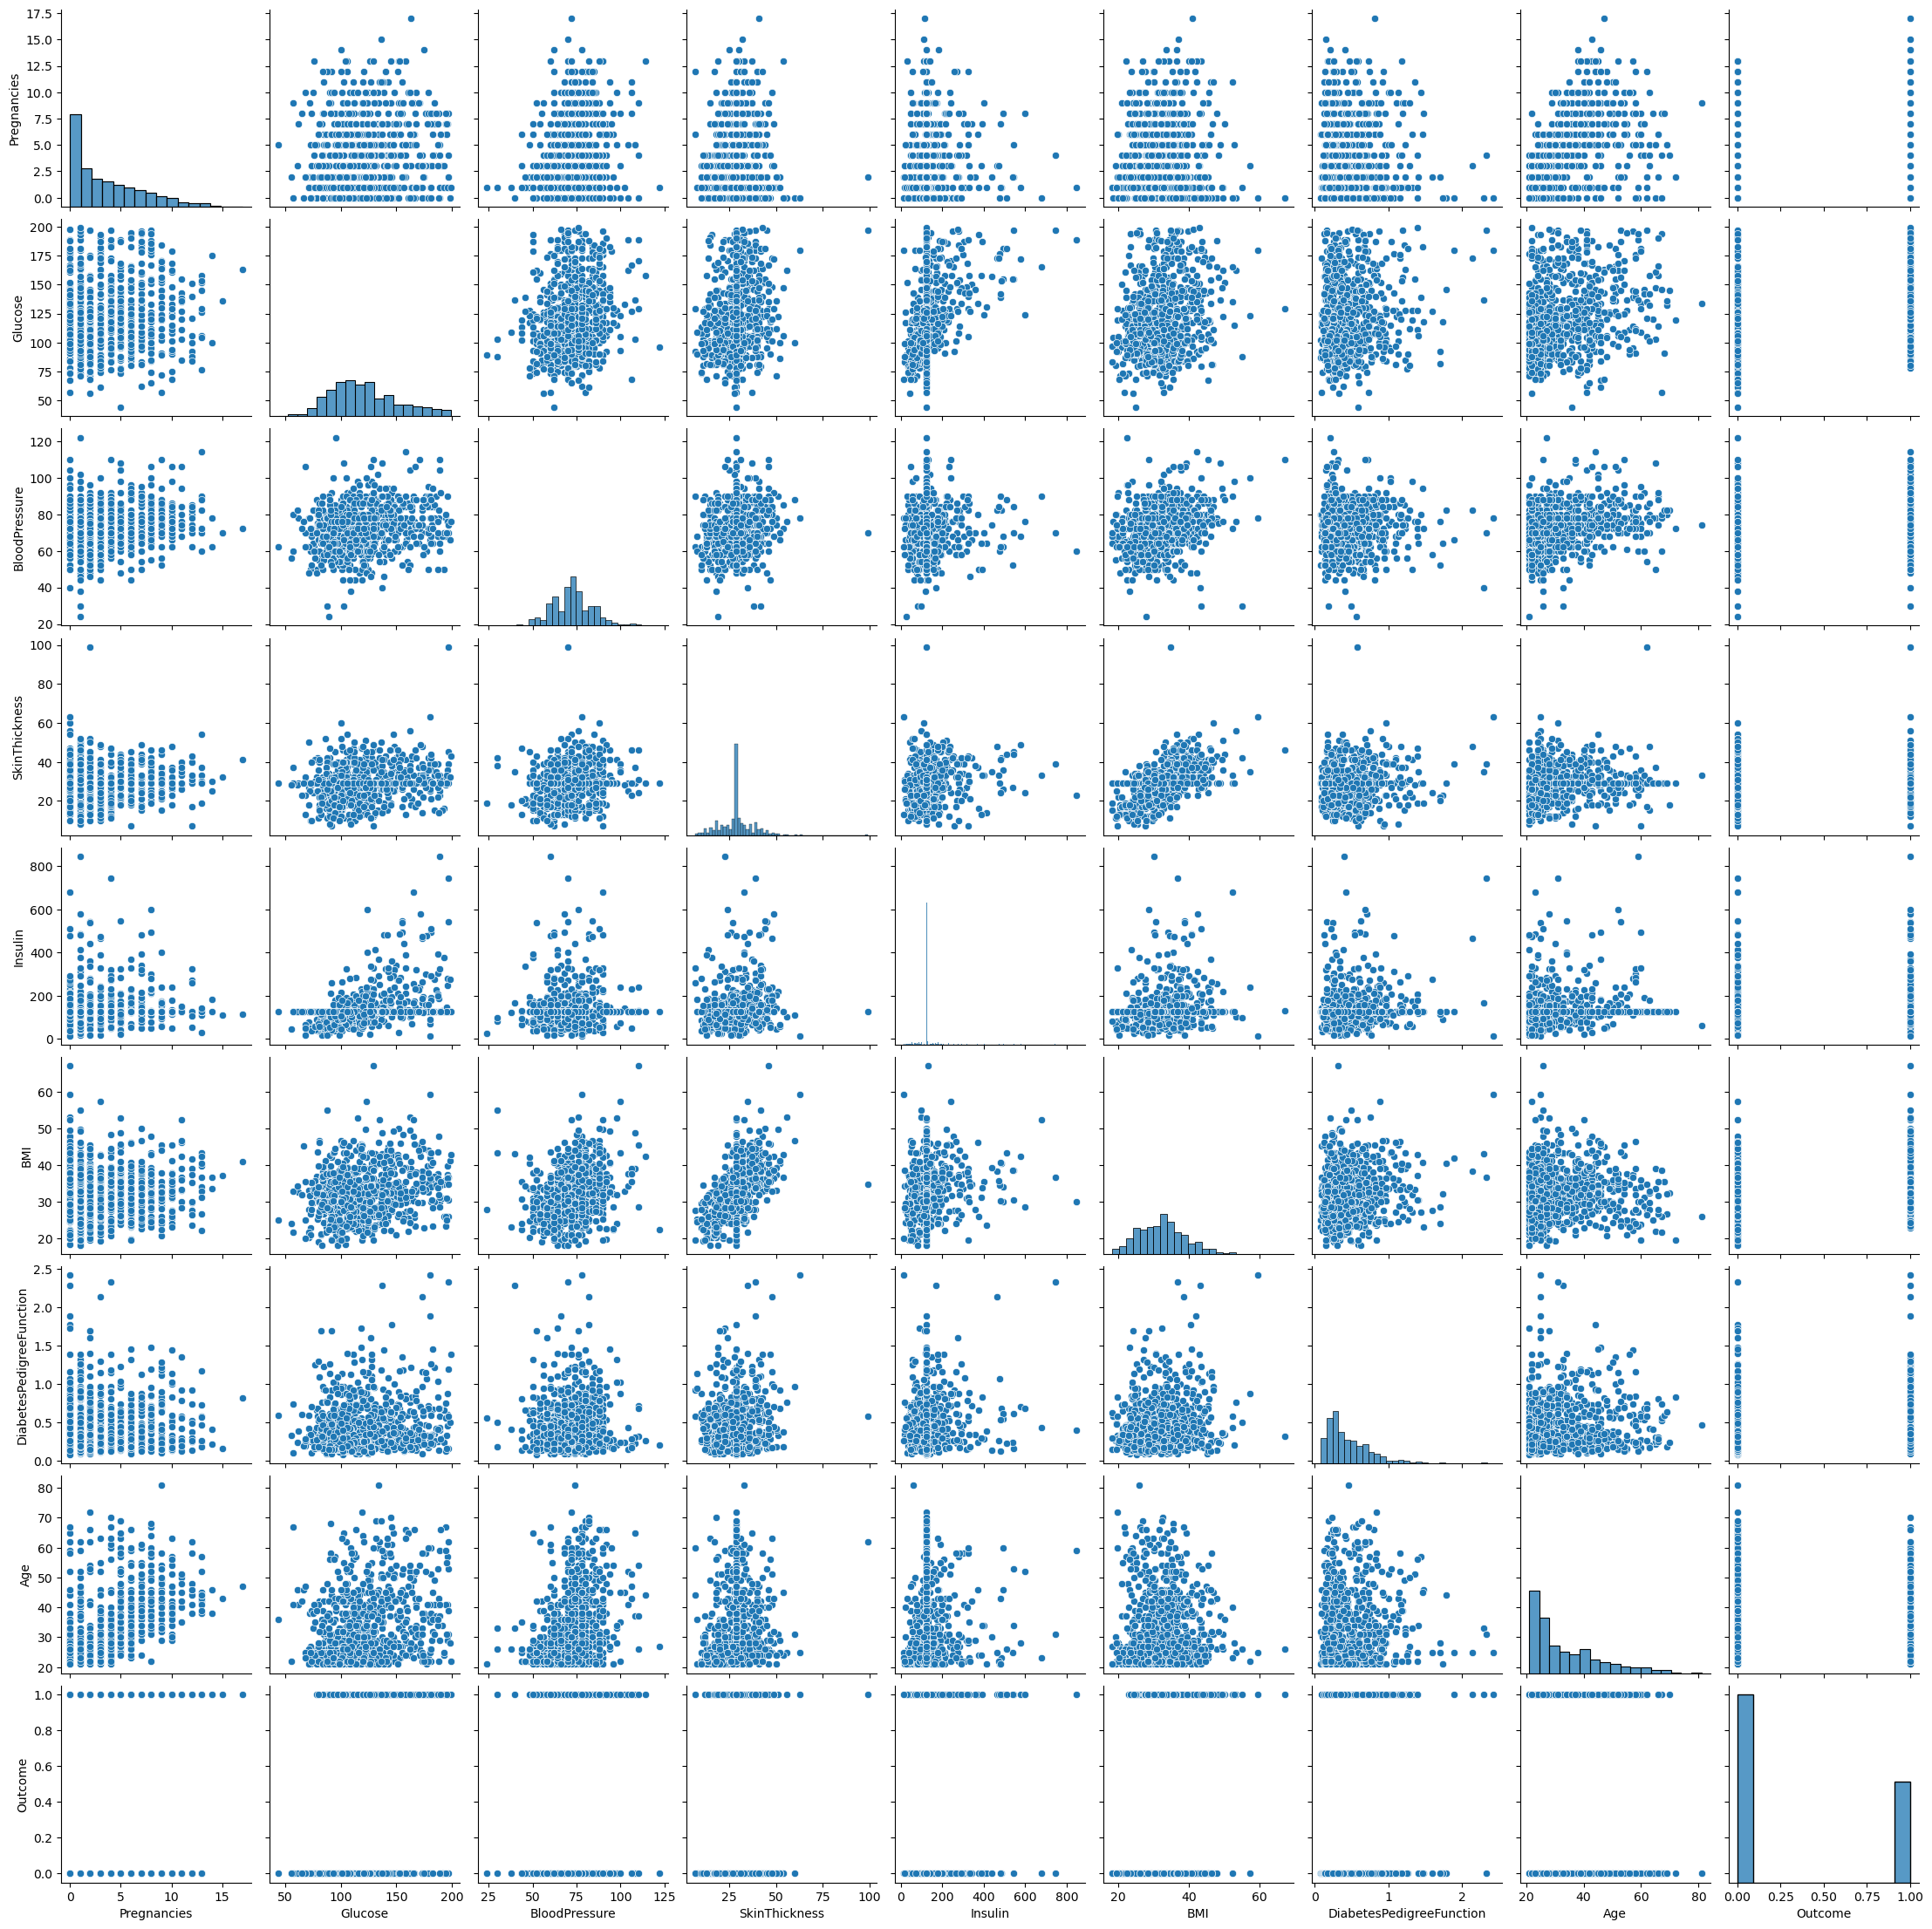

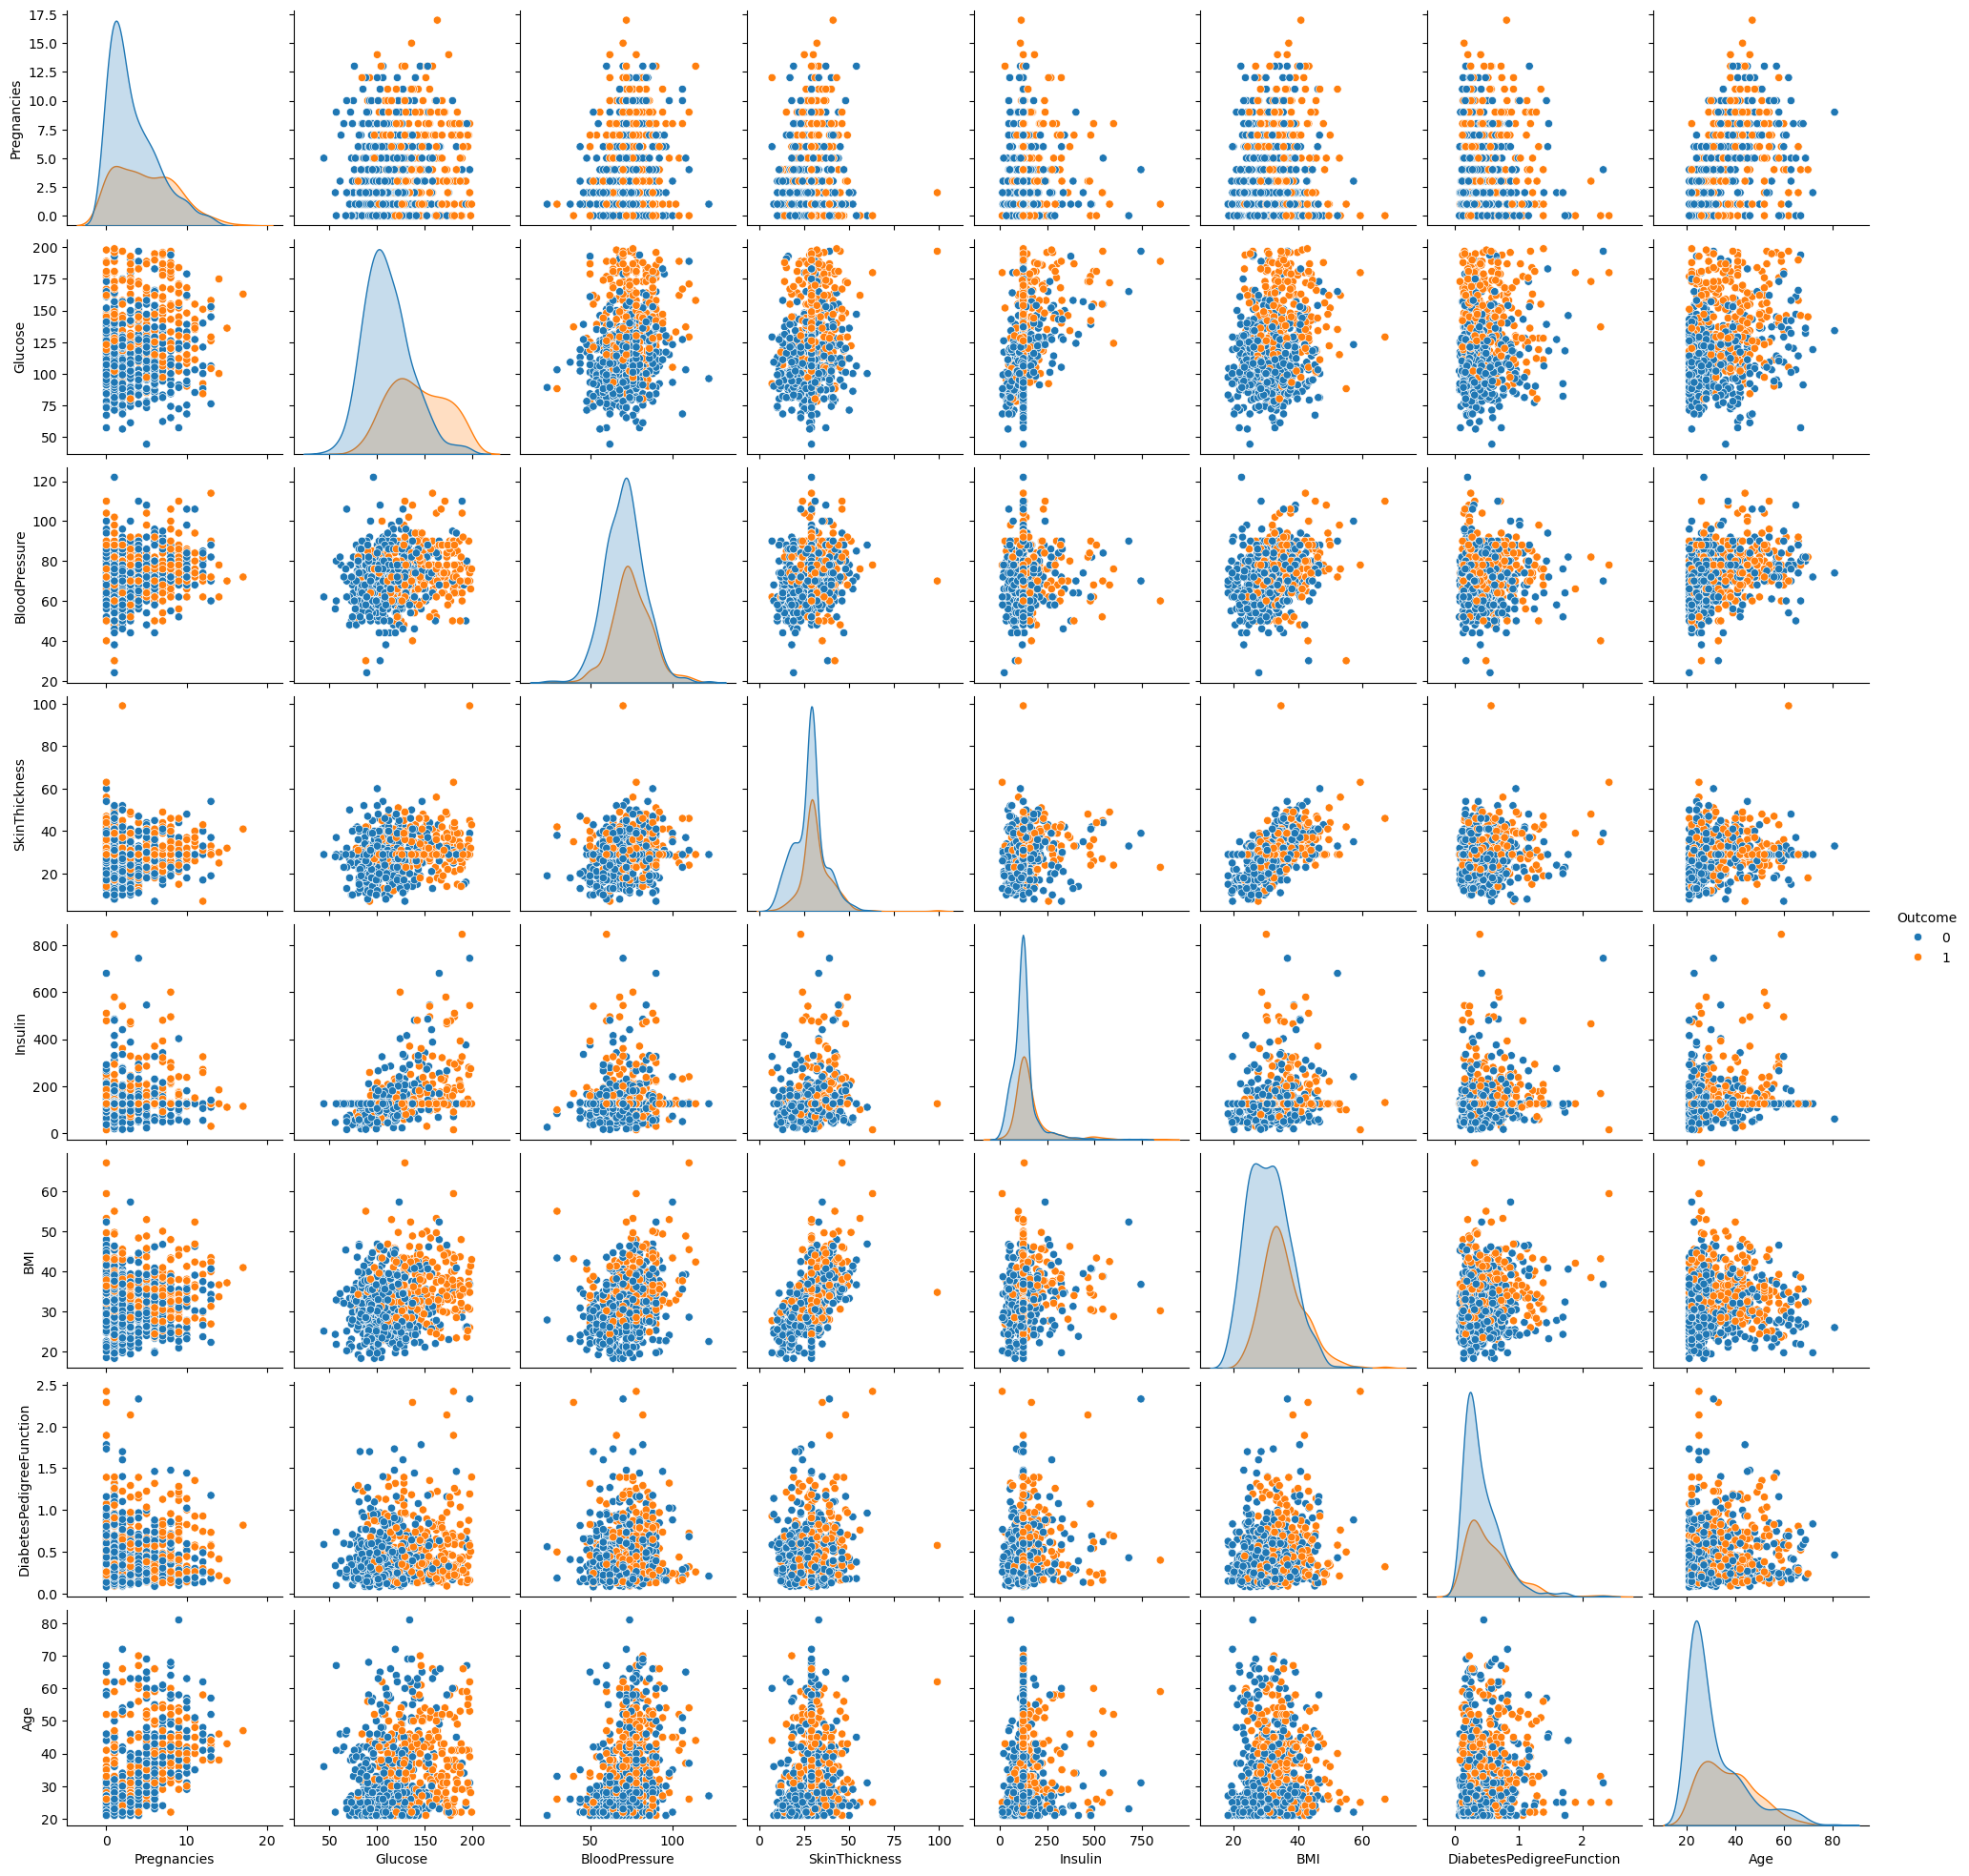

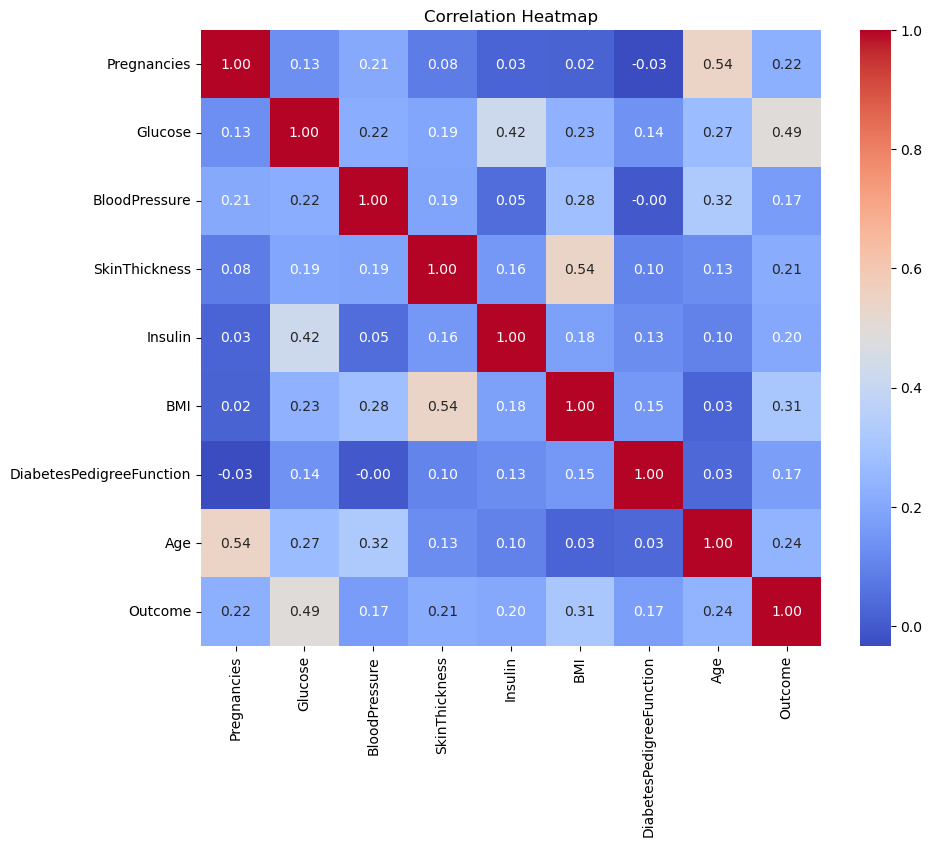

In [18]:
#Plot Scatter Matrix
sns.pairplot(data)
plt.show()

#Scatter Matrix with hue=Outcome
sns.pairplot(data, hue='Outcome')
plt.show()

#Plot Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
#Scaling the Data Before Modeling
X = data.drop('Outcome', axis=1)
y = data['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [20]:
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training data: (614, 8)
Testing data: (154, 8)

Training target:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing target:
Outcome
0    100
1     54
Name: count, dtype: int64


In [21]:
#Balancing Dataset using SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scaled,
    y_train
)

# Check class distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

After SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


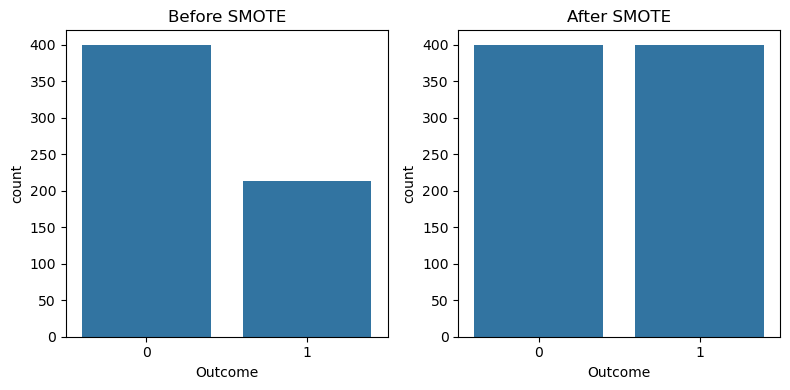

In [22]:
#visualization
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Before SMOTE")

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote)
plt.title("After SMOTE")

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import accuracy_score

In [24]:
#Finding Best K for KNN
k_values = range(1, 21)

training_accuracy = []
testing_accuracy = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(x_train_smote, y_train_smote)

    train_pred = knn.predict(x_train_smote)
    test_pred = knn.predict(x_test_scaled)

    training_accuracy.append(
        accuracy_score(y_train_smote, train_pred)
    )

    testing_accuracy.append(
        accuracy_score(y_test, test_pred)
    )
# Results
results = pd.DataFrame({
    "K": list(k_values),
    "Training Accuracy": training_accuracy,
    "Testing Accuracy": testing_accuracy
})

results

#best K according to testing accuracy:
best_k = results.loc[
    results["Testing Accuracy"].idxmax(),
    "K"
]

print("Best K:", best_k)

Best K: 2


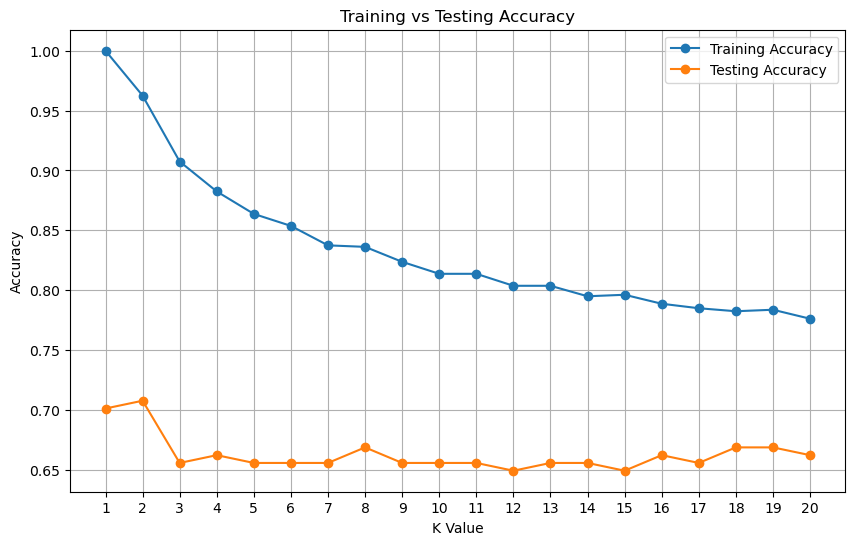

In [25]:
#plot Training and Testing accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    training_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    k_values,
    testing_accuracy,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")

plt.xticks(list(k_values))
plt.legend()
plt.grid()

plt.show()

In [26]:
# Final Model Evaluation with KNN

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(x_train_smote, y_train_smote)
y_pred = final_knn.predict(x_test_scaled)
print("predicted Values:")
print(y_pred)

final_accuracy = accuracy_score(y_test, y_pred)
print(
    "Final Model Accuracy:",
    round(final_accuracy*100, 2),
    "%"
)

predicted Values:
[1 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]
Final Model Accuracy: 70.78 %


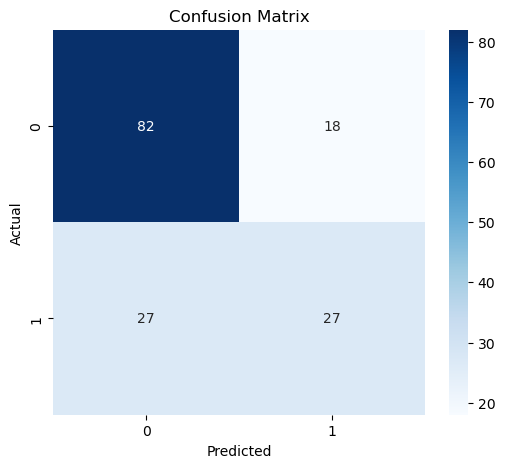

In [27]:
#confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [29]:
#Precision, recall and F1 score
precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Precision: 0.6
Recall: 0.5
F1 Score: 0.5455


In [30]:
#in oercentage
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

Precision: 60.0 %
Recall: 50.0 %
F1 Score: 54.55 %


In [31]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

